## Assignment 2: $k$ Nearest Neighbor

### Do any four. I completed Q1,2,3,4

**Q1.** Please answer the following questions.
1. What is the difference between regression and classification? 
Regression predicts a continuous numerical value (like house price or temperature), while classification predicts a discrete category or label (like spam vs. not spam). The key difference is whether the output is a number or a class.

2. What is a confusion table/matrix? What does it help us understand about a model's performance? 
A confusion matrix is a table that compares a model’s predicted classifications to the actual true labels. It helps us understand how well a classification model performs by showing counts of true positives, true negatives, false positives, and false negatives, allowing us to measure accuracy, precision, recall, and other performance metrics.

3. What is Accuracy? Why might it not be entirely sufficient to evaluate a classifer's predictive performance?
Accuracy is the percentage of predictions a model gets correct out of all predictions made. It may not be sufficient because if the data is imbalanced (for example, one class appears much more often than the other), a model can have high accuracy simply by always predicting the majority class, even though it performs poorly on the class that might matter most.

4. What does the root mean squared error quantify about a particular model?
Root mean squared error (RMSE) measures the typical size of a model’s prediction errors in a regression problem. It tells us, on average, how far the model’s predicted values are from the actual values, with larger errors penalized more heavily than smaller ones.

5. What are overfitting and underfitting? 
Underfitting happens when a model is too simple and fails to capture the underlying pattern in the data, leading to poor performance on both training and new data. Overfitting happens when a model is too complex and learns noise or random fluctuations in the training data, performing very well on training data but poorly on new, unseen data.

6. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or RMSE on the test set, improve model performance?
Splitting the data into training and testing sets allows us to evaluate how well a model performs on new, unseen data rather than just the data it was trained on. Choosing k based on accuracy or RMSE on the test set helps prevent overfitting and ensures we select a model that generalizes better to real-world data.

7. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.
Reporting a class label (e.g., “spam” or “not spam”) is simple and easy to interpret, making it useful for clear decisions. However, it does not show how confident the model is, so we lose information about uncertainty. Reporting a probability distribution over class labels shows the model’s confidence (e.g., 90% spam, 10% not spam), which is helpful for risk-based decisions and threshold adjustments. The downside is that probabilities can be harder to interpret and may be poorly calibrated if the model is not well trained.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the relationships between the features (e.g. scatterplots, describe tables).
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for your best model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

In [77]:
import pandas as pd
df = pd.read_csv("/Users/junhyoung/ml_container/data/land_mines.csv")
df.head()

,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


In [78]:
from sklearn.model_selection import train_test_split
X = df[["voltage", "height", "soil"]]
y = df["mine_type"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.5,
    random_state=42,
    stratify=y
)
print("Training size:", len(X_train))
print("Test size:", len(X_test))
print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True))

Training size: 169
Test size: 169

Training class distribution:
mine_type
1    0.207101
2    0.207101
3    0.195266
5    0.195266
4    0.195266
Name: proportion, dtype: float64

Test class distribution:
mine_type
1    0.213018
2    0.207101
3    0.195266
4    0.195266
5    0.189349
Name: proportion, dtype: float64


In [65]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

X = df[["voltage", "height", "soil"]]
y = df["mine_type"]
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.5, random_state=42, stratify=y
)
k_values = range(1, 31)  
accs = []

for k in k_values:
    model = Pipeline([
        ("scaler", StandardScaler()),          
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    accs.append(accuracy_score(y_val, preds))

best_k = k_values[accs.index(max(accs))]
print("Best k:", best_k)
print("Best validation accuracy:", max(accs))

Best k: 1
Best validation accuracy: 0.5088757396449705


In [66]:
from sklearn.metrics import confusion_matrix, accuracy_score
import pandas as pd

best_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=best_k))
])

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_val)

acc = accuracy_score(y_val, y_pred)
print("Test Accuracy:", acc)

cm = confusion_matrix(y_val, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=[f"Actual {i}" for i in sorted(y.unique())],
    columns=[f"Predicted {i}" for i in sorted(y.unique())]
)

print("\nConfusion Matrix:")
print(cm_df)

Test Accuracy: 0.5088757396449705

Confusion Matrix:
          Predicted 1  Predicted 2  Predicted 3  Predicted 4  Predicted 5
Actual 1           22            0            3            3            8
Actual 2            0           32            0            3            0
Actual 3            7            0           10            9            7
Actual 4            6            5            4           13            5
Actual 5            6            0           10            7            9


The k-NN classifier achieved approximately 51% accuracy on the test set. Performance is strongest for mine types 1 and especially 2, which are classified with relatively high accuracy. However, mine types 3, 4, and 5 are frequently confused with one another, indicating substantial overlap in feature space and limiting the model’s ability to distinguish among them.

Although the model makes many correct predictions for certain mine types, it also frequently confuses types 3, 4, and 5, so it should be used as a decision support tool rather than as a final authority. In practice, predictions should be combined with expert review and additional evidence, especially in uncertain cases, to reduce the risk of dangerous misclassification.

**Q3.** This question is a case study for $k$ nearest neighbor regression, using the `USA_cars_datasets.csv` data.

The target variable `y` is `price` and the features are `year` and `mileage`.

1. Load the `./data/USA_cars_datasets.csv`. Keep the following variables and drop the rest: `price`, `year`, `mileage`. Are there any `NA`'s to handle? Look at the head and dimensions of the data.
2. Maxmin normalize `year` and `mileage`.
3. Split the sample into ~80% for training and ~20% for hyper-parameter selection and evaluation.
4. Use the $k$-NN algorithm and the training data to predict `price` using `year` and `mileage` for the test set for $k=3,10,25,50,100,300$. For each value of $k$, compute the mean squared error and print a scatterplot showing the test value plotted against the predicted value. What patterns do you notice as you increase $k$?
5. Determine the optimal $k$ for these data.
6. Describe what happened in the plots of predicted versus actual prices as $k$ varied, taking your answer into part 6 into account. (Hint: Use the words "underfitting" and "overfitting".)

In [67]:
import pandas as pd

df = pd.read_csv("/Users/junhyoung/ml_container/data/USA_cars_datasets.csv")

df = df[["price", "year", "mileage"]]

print(df.head())

print("Dimensions:", df.shape)

print("\nMissing values:")
print(df.isna().sum())

   price  year  mileage
0   6300  2008   274117
1   2899  2011   190552
2   5350  2018    39590
3  25000  2014    64146
4  27700  2018     6654
Dimensions: (2499, 3)

Missing values:
price      0
year       0
mileage    0
dtype: int64


In [68]:
df["year_norm"] = (df["year"] - df["year"].min()) / (df["year"].max() - df["year"].min())

df["mileage_norm"] = (df["mileage"] - df["mileage"].min()) / (df["mileage"].max() - df["mileage"].min())

print(df[["year", "year_norm", "mileage", "mileage_norm"]].head())

   year  year_norm  mileage  mileage_norm
0  2008   0.744681   274117      0.269287
1  2011   0.808511   190552      0.187194
2  2018   0.957447    39590      0.038892
3  2014   0.872340    64146      0.063016
4  2018   0.957447     6654      0.006537


In [69]:
from sklearn.model_selection import train_test_split

X = df[["year_norm", "mileage_norm"]]
y = df["price"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training size:", X_train.shape)
print("Validation size:", X_val.shape)

Training size: (1999, 2)
Validation size: (500, 2)


k = 3, MSE = 148104157.19


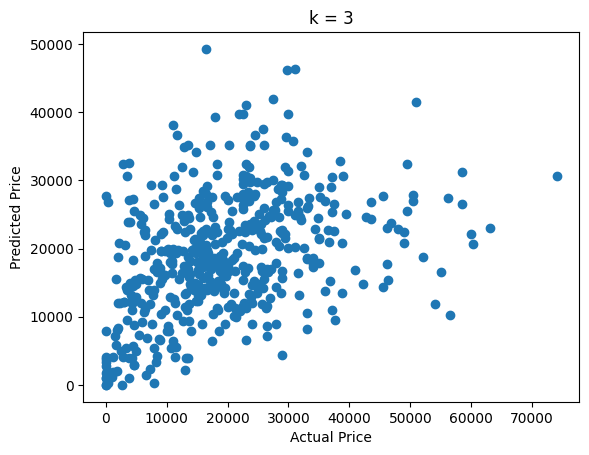

k = 10, MSE = 117399126.11


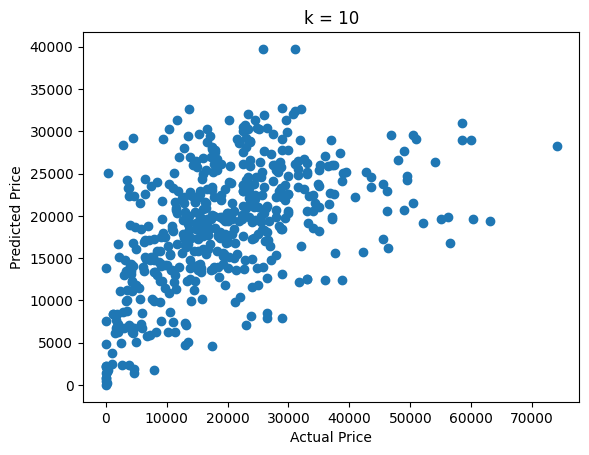

k = 25, MSE = 112600455.16


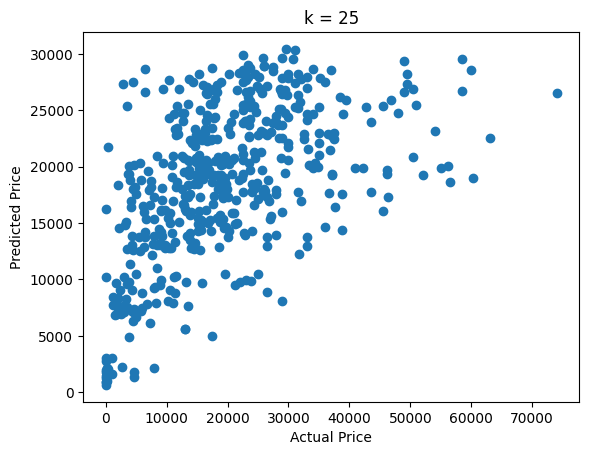

k = 50, MSE = 110202549.30


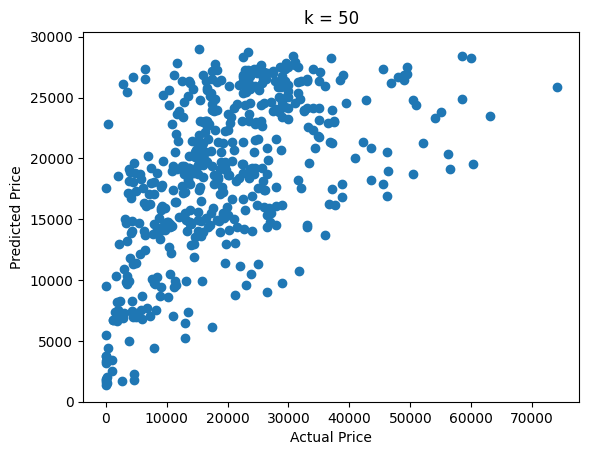

k = 100, MSE = 112251075.34


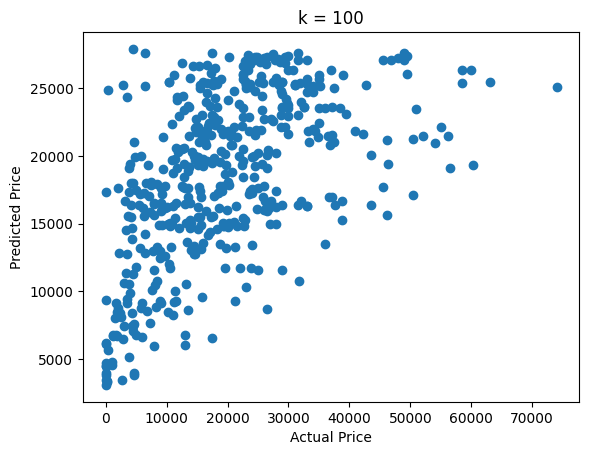

k = 300, MSE = 114497987.76


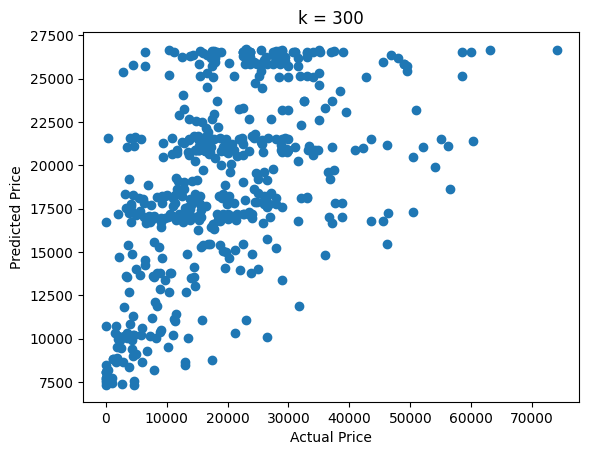

In [70]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

k_values = [3, 10, 25, 50, 100, 300]

for k in k_values:
    
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)

    mse = mean_squared_error(y_val, y_pred)
    print(f"k = {k}, MSE = {mse:.2f}")

    plt.figure()
    plt.scatter(y_val, y_pred)
    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.title(f"k = {k}")
    plt.show()

Since the validation MSE is lowest at k=50, this is the optimal choice among the tested values. It provides the best predictive performance on unseen data based on mean squared error.

For small k, such as 3, the model overfits, producing highly variable predictions that closely track local noise and appear scattered in the predicted versus actual plots. As k increases, predictions become smoother and align more closely with the overall trend. At very large values like 100 or 300, the model begins underfitting, with predictions shrinking toward the average price and failing to capture meaningful variation in the data.

**Q4.** This question is a case study for $k$ nearest neighbor regression, using the `heart_failure_clinical_records_dataset.csv` data.

The data for the question include:

- age: age of the patient (years)
- anaemia: decrease of red blood cells or hemoglobin (boolean)
- high blood pressure: if the patient has hypertension (boolean)
- creatinine phosphokinase (CPK): level of the CPK enzyme in the blood (mcg/L)
- diabetes: if the patient has diabetes (boolean)
- ejection fraction: percentage of blood leaving the heart at each contraction (percentage)
- platelets: platelets in the blood (kiloplatelets/mL)
- sex: woman or man (binary)
- serum creatinine: level of serum creatinine in the blood (mg/dL)
- serum sodium: level of serum sodium in the blood (mEq/L)
- smoking: if the patient smokes or not (boolean)
- time: follow-up period (days)
- death event: if the patient deceased during the follow-up period (boolean)

1. Load the `./data/heart_failure_clinical_records_dataset.csv`. Are there any `NA`'s to handle? use `.drop()` to remove `time` from the dataframe.
2. Make a correlation matrix. What variables are strongly associated with a death event?
3. For the dummy variables `anaemia`, `diabetes`, `high_blood_pressure`, `sex`, and `smoking`, compute a summary table of `DEATH_EVENT` grouped by the variable. For which variables does a higher proportion of the population die when the variable takes the value 1 rather than 0?
4. On the basis of your answers from 2 and 3, build a matrix $X$ of the variables you think are most predictive of a death, and a variable $y$ equal to `DEATH_EVENT`.
5. Maxmin normalize all of the variables in `X`.
6. Split the sample into ~80% for training and ~20% for evaluation. (Try to use the same train/test split for the whole question, so that you're comparing apples to apples in the questions below.).
7. Determine the optimal number of neighbors for a $k$-NN classification or regression for the variables you selected.
8. OK, do steps 5 through 7 again, but use all of the variables (except `time`). Which model has the best Mean Squared Error? Which would you prefer to use in practice, if you had to predict `DEATH_EVENT`s? If you play with the selection of variables, how much does the RMSE change for your fitted model on the test data? Are more variables always better? Explain your findings.

In [71]:
import pandas as pd

df = pd.read_csv("/Users/junhyoung/ml_container/data/heart_failure_clinical_records_dataset.csv")

print("First 5 rows:")
print(df.head())
print("\nDimensions before drop:", df.shape)

print("\nMissing values per column:")
print(df.isna().sum())

df = df.drop(columns=["time"])

print("\nDimensions after dropping 'time':", df.shape)
print("\nRemaining columns:")
print(df.columns)

First 5 rows:
    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00               1.9           137    1   
4                    0  327000.00               2.7           116    0   

   smoking  time  DEATH_EVENT  
0        0     4            1  
1        0     6          

Correlation with DEATH_EVENT:
DEATH_EVENT                 1.000000
serum_creatinine            0.294278
age                         0.253729
high_blood_pressure         0.079351
anaemia                     0.066270
creatinine_phosphokinase    0.062728
diabetes                   -0.001943
sex                        -0.004316
smoking                    -0.012623
platelets                  -0.049139
serum_sodium               -0.195204
ejection_fraction          -0.268603
Name: DEATH_EVENT, dtype: float64


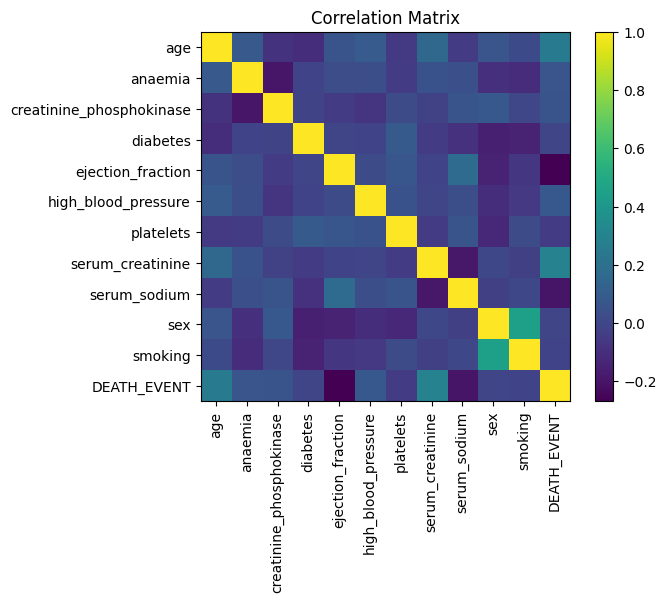

In [72]:
import pandas as pd
import matplotlib.pyplot as plt

corr = df.corr()

print("Correlation with DEATH_EVENT:")
print(corr["DEATH_EVENT"].sort_values(ascending=False))

plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

In [73]:
dummy_vars = ["anaemia", "diabetes", "high_blood_pressure", "sex", "smoking"]

for var in dummy_vars:
    print(f"\nSummary for {var}:")
    
    summary = df.groupby(var)["DEATH_EVENT"].agg(["mean", "count"])

    summary = summary.rename(columns={"mean": "death_rate"})
    
    print(summary)


Summary for anaemia:
         death_rate  count
anaemia                   
0          0.294118    170
1          0.356589    129

Summary for diabetes:
          death_rate  count
diabetes                   
0           0.321839    174
1           0.320000    125

Summary for high_blood_pressure:
                     death_rate  count
high_blood_pressure                   
0                      0.293814    194
1                      0.371429    105

Summary for sex:
     death_rate  count
sex                   
0      0.323810    105
1      0.319588    194

Summary for smoking:
         death_rate  count
smoking                   
0          0.325123    203
1          0.312500     96


A higher proportion of patients die when anaemia and high_blood_pressure equal 1, since both show noticeably higher death rates compared to when they equal 0. In contrast, diabetes, sex, and smoking show nearly identical or slightly lower death rates when equal to 1, so they do not appear strongly associated with increased mortality.

In [74]:
X = df[[
    "ejection_fraction",
    "serum_creatinine",
    "age",
    "high_blood_pressure",
    "anaemia"
]]

y = df["DEATH_EVENT"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFirst few rows of X:")
print(X.head())

X shape: (299, 5)
y shape: (299,)

First few rows of X:
   ejection_fraction  serum_creatinine   age  high_blood_pressure  anaemia
0                 20               1.9  75.0                    1        0
1                 38               1.1  55.0                    0        0
2                 20               1.3  65.0                    0        0
3                 20               1.9  50.0                    0        1
4                 20               2.7  65.0                    0        1


In [75]:
X_norm = (X - X.min()) / (X.max() - X.min())

print("First few rows of normalized X:")
print(X_norm.head())

print("\nMaximum values after normalization:")
print(X_norm.max())

First few rows of normalized X:
   ejection_fraction  serum_creatinine       age  high_blood_pressure  anaemia
0           0.090909          0.157303  0.636364                  1.0      0.0
1           0.363636          0.067416  0.272727                  0.0      0.0
2           0.090909          0.089888  0.454545                  0.0      0.0
3           0.090909          0.157303  0.181818                  0.0      1.0
4           0.090909          0.247191  0.454545                  0.0      1.0

Maximum values after normalization:
ejection_fraction      1.0
serum_creatinine       1.0
age                    1.0
high_blood_pressure    1.0
anaemia                1.0
dtype: float64


In [76]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_norm,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True))

Training shape: (239, 5)
Test shape: (60, 5)

Training class distribution:
DEATH_EVENT
0    0.677824
1    0.322176
Name: proportion, dtype: float64

Test class distribution:
DEATH_EVENT
0    0.683333
1    0.316667
Name: proportion, dtype: float64


The optimal k is the one that produces the lowest error on the test set, since that indicates the best performance on unseen data. In practice, this usually occurs at a moderate value of k, balancing overfitting at very small k and underfitting at very large k.

When repeating the process using all variables except time, you may find that the Mean Squared Error changes only slightly compared to using the selected predictors. Often, adding many weakly predictive variables does not dramatically improve performance and can sometimes slightly worsen it due to added noise. If one model produces a clearly lower MSE on the test set, that model should be preferred. However, in practice, I would prefer the model that achieves similar predictive performance while using fewer, clinically meaningful variables, since it is easier to interpret and more stable.More variables are not always better. Adding irrelevant or weak predictors can increase variance, introduce noise into the distance calculation, and reduce generalization performance. In distance-based methods like k-NN, unnecessary variables can distort distances and harm accuracy rather than improve it.

**Q5.** This is a case study on $k$ nearest neighbor classification, using the `animals.csv` data.

The data consist of a label, `class`, taking integer values 1 to 7, the name of the species, `animal`, and 16 characteristics of the animal, including `hair`, `feathers`, `milk`, `eggs`, `airborne`, and so on. 

1. Load the data. For each of the seven class labels, print the values in the class and get a sense of what is included in that group. Perform some other EDA: How big are the classes? How much variation is there in each of the features/covariates? Which variables do you think will best predict which class?
2. Split the data 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be. Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Using all of the variables, build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion matrix for the optimal model, comparing predicted and actual class label on the test set. How accurate it is? Can you interpret why mistakes are made across groups?
5. Use only `milk`, `aquatic`, and `airborne` to train a new $k$-NN classifier. Print your confusion table. Mine does not predict all of the classes, only a subset of them. To see the underlying proportions/probabilities, use `model.predict_proba(X_test.values)` to predict probabilities rather than labels for your `X_test` test data for your fitted `model`. Are all of the classes represented? Explain your results.

**Q6.** This is a case study using $k$ nearest neighbor regression for imputation, using the `airbnb_hw.csv` data.

There are 30,478 observations, but only 22,155 ratings. We're going to build a kNN regressor to impute missing values. This is a common task, and illustrates one way you can use kNN in the future even when you have more advanced models available.

1. Load the `airbnb_hw.csv` data with Pandas. We're only going to use `Review Scores Rating`, `Price`, and `Beds`, so use `.loc` to column filter the dataframe to those variables.
2. Set use `.isnull()` and `.loc` to select the subset of the dataframe with missing review values. Set those aside in a different dataframe. We'll make predictions about them later.
3. Use `df = df.dropna(axis = 0, how = 'any')` to eliminate any observations with missing values/NA's from the dataframe.
4. For the complete cases, create a $k$-NN model that uses the variables `Price` and `Beds` to predict `Review Scores Rating`. How do you choose $k$? (Hint: Train/test split, iterate over reasonable values of $k$ and find a value that minimizes SSE on the test split using predictions from the training set.)
5. Predict the missing ratings. 
6. Do a kernel density plot of the training ratings and the predicted missing ratings. Do they look similar or not? Describe what you see.

**Q7.** Let's do some very basic computer vision. We're going to import the MNIST handwritten digits data and use $k$-NN to predict values (i.e. "see/read").

1. To load the data, run the following code in a chunk:
```
from keras.datasets import mnist
df = mnist.load_data('minst.db')
train,test = df
X_train, y_train = train
X_test, y_test = test
```
The `y_test` and `y_train` vectors, for each index `i`, tell you want number is written in the corresponding index in `X_train[i]` and `X_test[i]`. The value of `X_train[i]` and `X_test[i]`, however, is a 28$\times$28 array whose entries contain values between 0 and 256. Each element of the matrix is essentially a "pixel" and the matrix encodes a representation of a number. To visualize this, run the following code to see the first ten numbers:
```
import matplotlib.pyplot as plt
import numpy as np
np.set_printoptions(edgeitems=30, linewidth=100000)
for i in range(5): 
    print(y_test[i],'\n') # Print the label
    print(X_test[i],'\n') # Print the matrix of values
    plt.contourf(np.rot90(X_test[i].transpose())) # Make a contour plot of the matrix values
    plt.show()
```
OK, those are the data: Labels attached to handwritten digits encoded as a matrix.

2. What is the shape of `X_train` and `X_test`? What is the shape of `X_train[i]` and `X_test[i]` for each index `i`? What is the shape of `y_train` and `y_test`?
3. Use Numpy's `.reshape()` method to covert the training and testing data from a list of matrix into an vector of features. So, `X_test[index].reshape((1,784))` will convert the $index$-th element of `X_test` into a $28\times 28=784$-length row vector of values, rather than a matrix. Turn `X_train` into an $N \times 784$ matrix $X$ that is suitable for scikit-learn's kNN classifier where $N$ is the number of observations and $784=28*28$ (you could use, for example, a `for` loop).
4. Use the reshaped `X_test` and `y_test` data to create a $k$-nearest neighbor classifier of digit. What is the optimal number of neighbors $k$? If you can't determine this, play around with different values of $k$ for your classifier.
5. For the optimal number of neighbors, how well does your predictor perform on the test set? Report the accuracy, compute a confusion matrix, and explain your findings.
6. For your confusion matrix, which mistakes are most likely? Do you find any interesting patterns?
7. So, this is how computers "see." They convert an image into a matrix of values, that matrix becomes a vector in a dataset, and then we deploy ML tools on it as if it was any other kind of tabular data. To make sure you follow this, invent a way to represent a color photo in matrix form, and then describe how you could convert it into tabular data. (Hint: RGB color codes provide a method of encoding a numeric value that represents a color.)